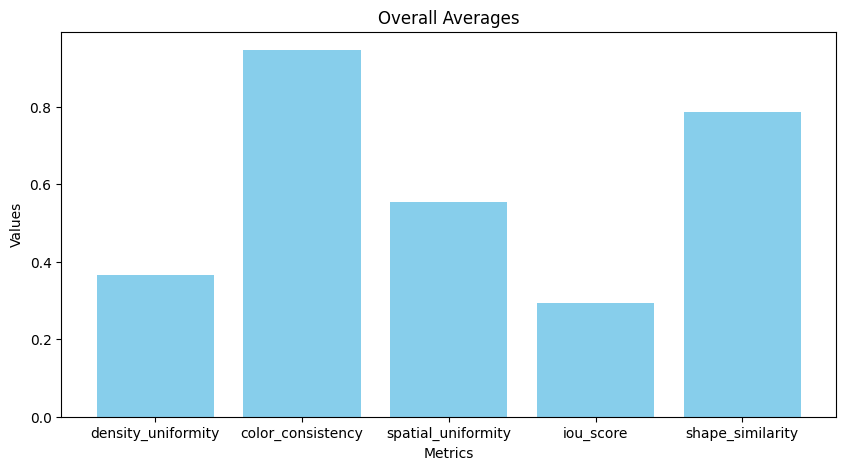

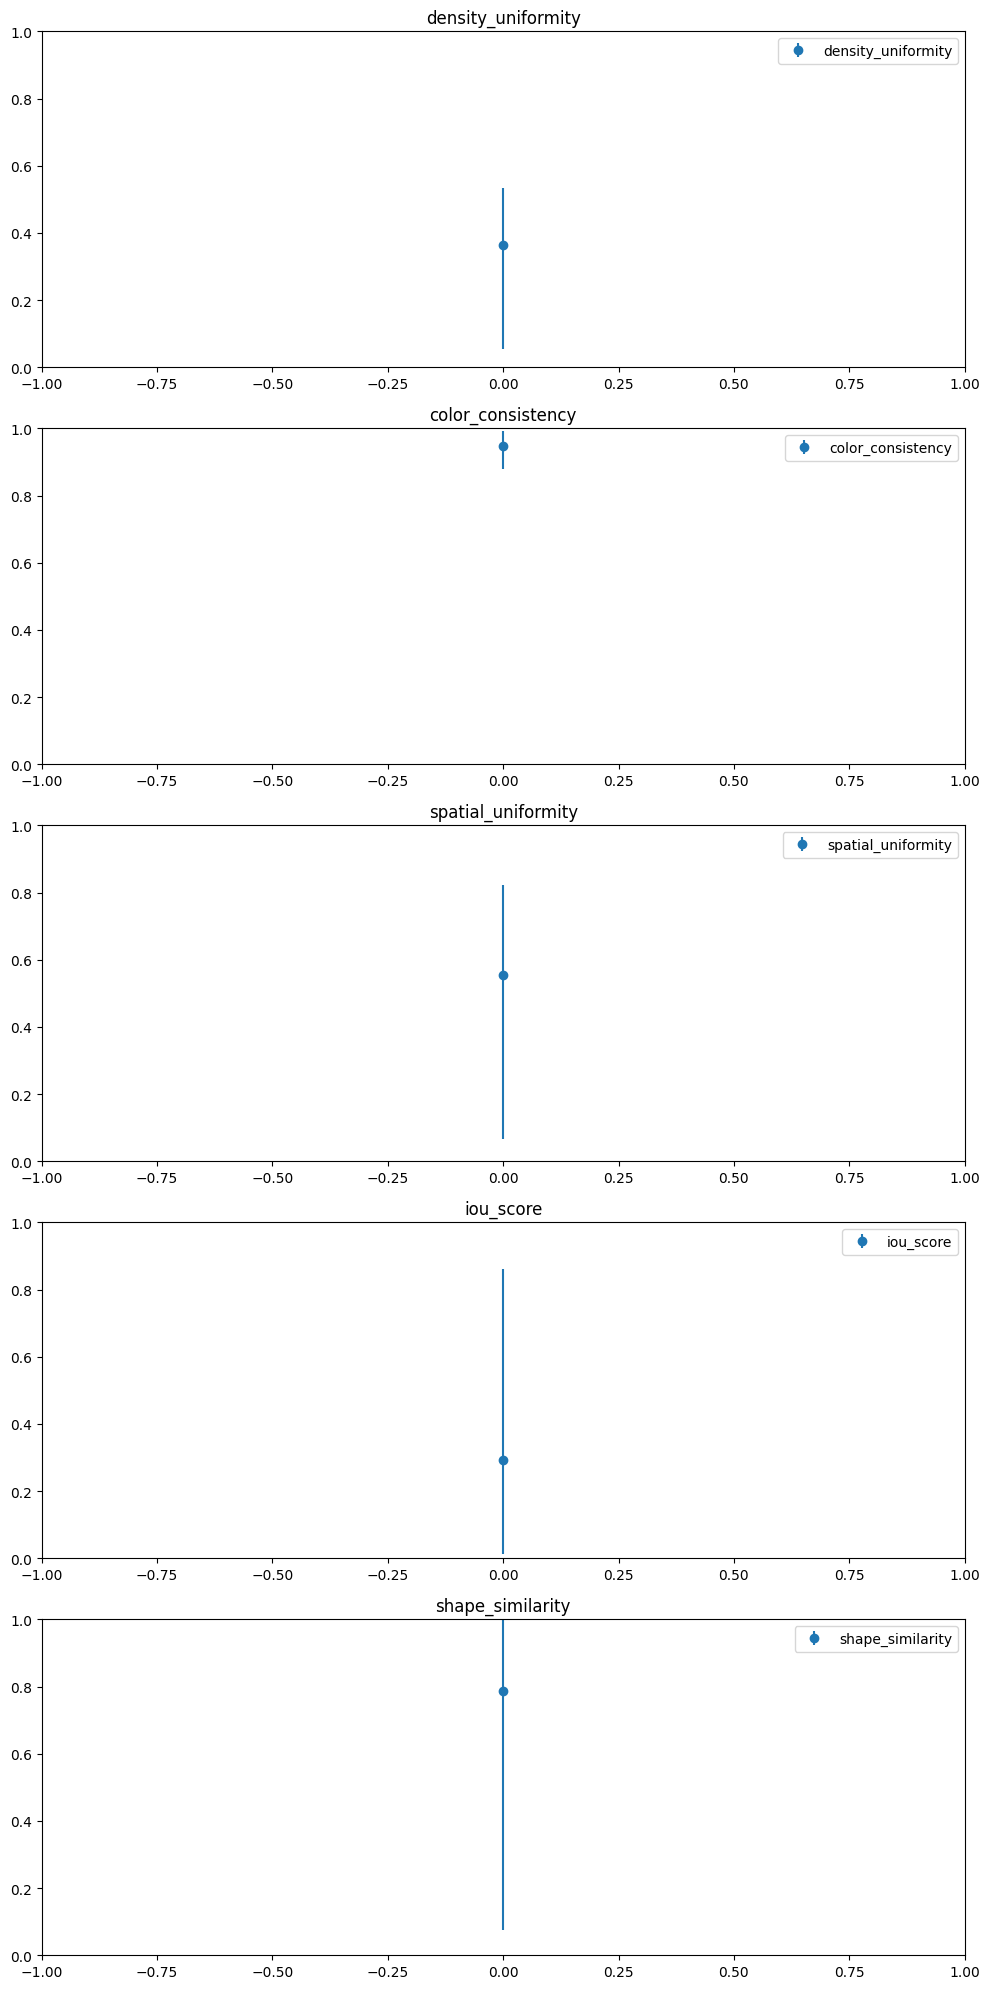

In [1]:
import numpy as np

import matplotlib.pyplot as plt

# Data
results = {
    "total_products": 167,
    "categories": [
        "category",
        "furniture",
        "office",
        "other",
        "electronics",
        "outdoor",
        "fashion",
        "beauty",
        "health and fitness",
        "decoration",
        "kitchen"
    ],
    "timestamp": "2025-02-13T23:33:17.745874",
    "overall_averages": {
        "density_uniformity": 0.36481731527377,
        "color_consistency": 0.9463087596377745,
        "spatial_uniformity": 0.5541466001121481,
        "iou_score": 0.29324891920281965,
        "shape_similarity": 0.7870590685416314
    },
    "overall_distributions": {
        "density_uniformity": {
            "min": 0.05343957816260669,
            "max": 0.5348722675275224,
            "mean": 0.36481731527376976,
            "std": 0.09320697029222443
        },
        "color_consistency": {
            "min": 0.8784077061448102,
            "max": 0.9911405179889831,
            "mean": 0.9463087596377748,
            "std": 0.021813749115848206
        },
        "spatial_uniformity": {
            "min": 0.06740215168230279,
            "max": 0.8233413291732903,
            "mean": 0.5541466001121481,
            "std": 0.08757238795244159
        },
        "iou_score": {
            "min": 0.011372251705837756,
            "max": 0.8596243402669979,
            "mean": 0.2932489192028197,
            "std": 0.166279498298185
        },
        "shape_similarity": {
            "min": 0.07494073955849144,
            "max": 0.9998770010656705,
            "mean": 0.7870590685416311,
            "std": 0.2877387486926469
        }
    }
}

# Plot overall averages
averages = results["overall_averages"]
labels = list(averages.keys())
values = list(averages.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Overall Averages')
plt.show()

# Plot overall distributions
distributions = results["overall_distributions"]

fig, axs = plt.subplots(5, 1, figsize=(10, 20))

for i, (metric, stats) in enumerate(distributions.items()):
    axs[i].errorbar(x=[0], y=[stats["mean"]], yerr=[[stats["mean"] - stats["min"]], [stats["max"] - stats["mean"]]], fmt='o', label=metric)
    axs[i].set_title(metric)
    axs[i].set_xlim(-1, 1)
    axs[i].set_ylim(0, 1)
    axs[i].legend()

plt.tight_layout()
plt.show()

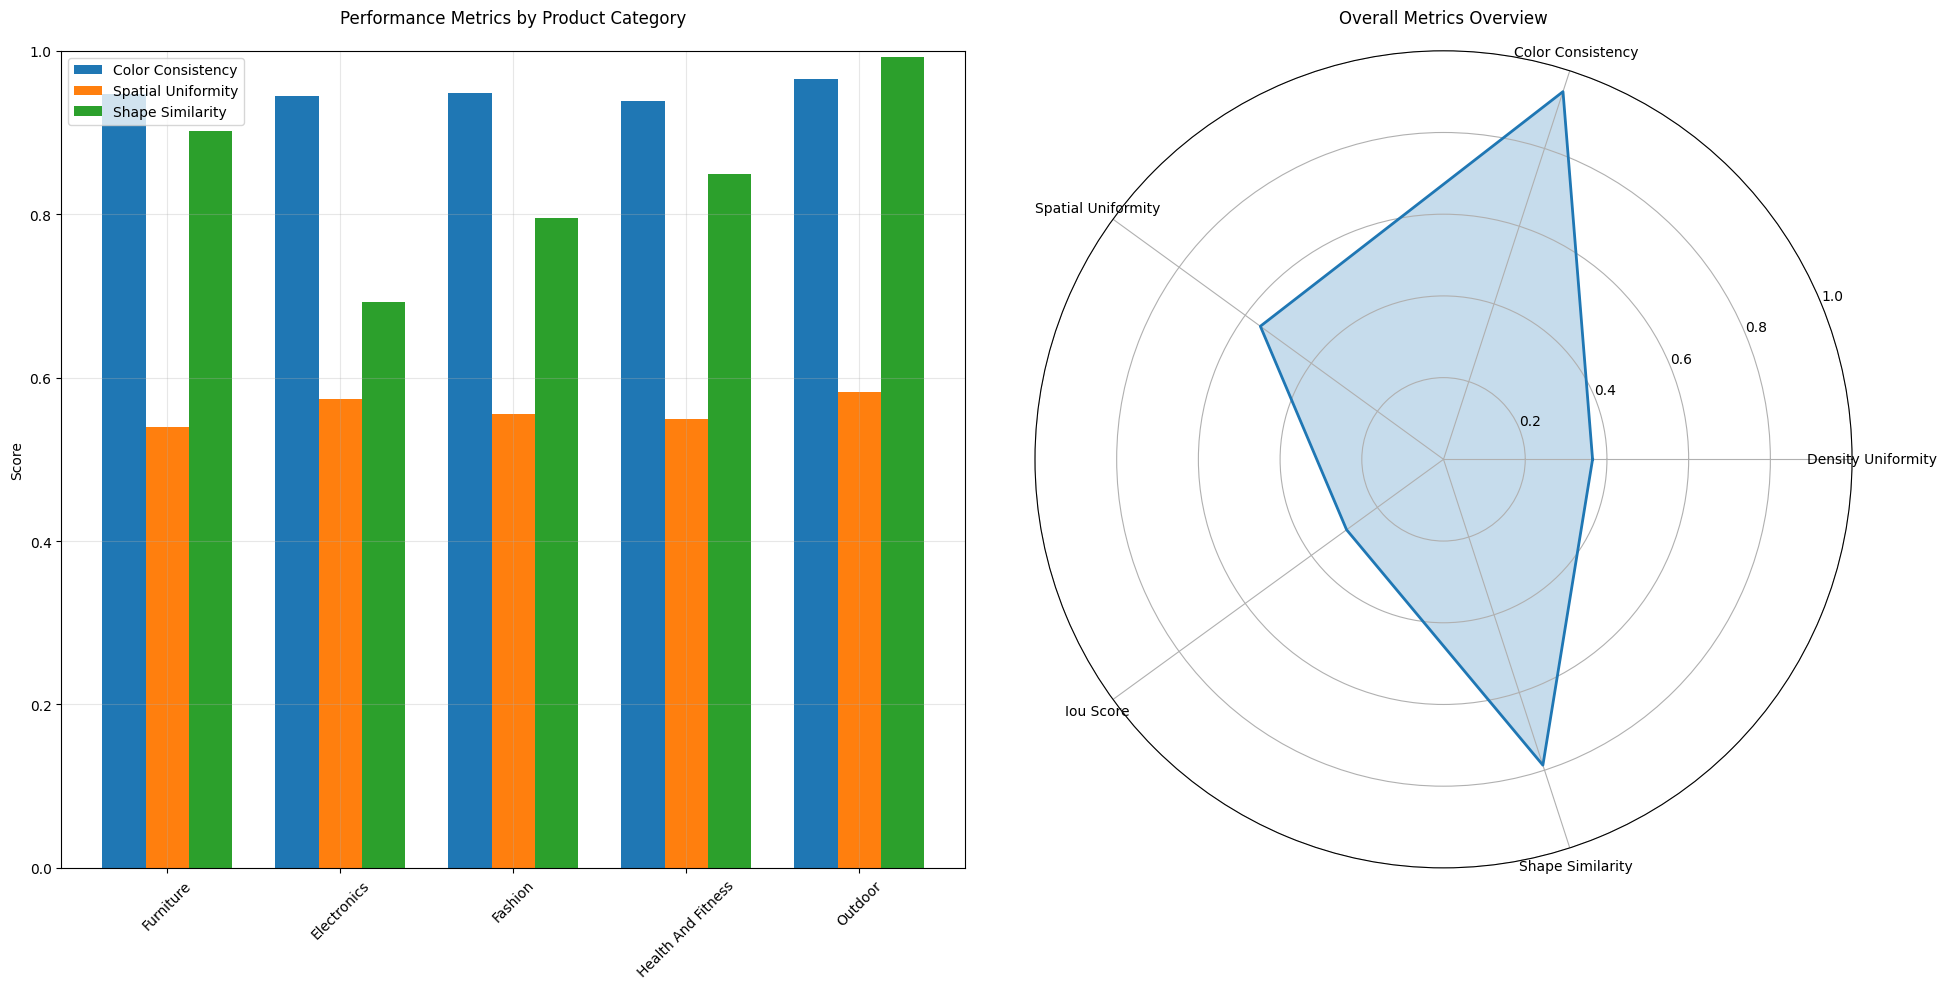

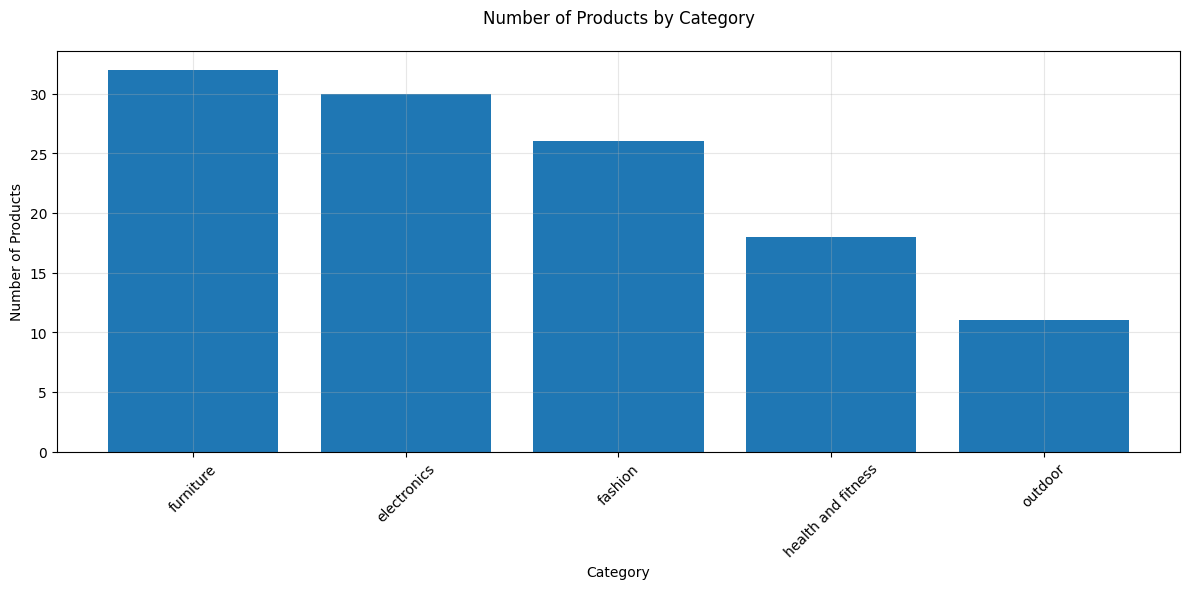

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load and process the data
data = {
    "total_products": 167,
    "categories": ["category", "furniture", "office", "other", "electronics", "outdoor", "fashion", "beauty", "health and fitness", "decoration", "kitchen"],
    "overall_averages": {
        "density_uniformity": 0.36481731527377,
        "color_consistency": 0.9463087596377745,
        "spatial_uniformity": 0.5541466001121481,
        "iou_score": 0.29324891920281965,
        "shape_similarity": 0.7870590685416314
    },
    "category_analysis": {
        "furniture": {
            "product_count": 32,
            "averages": {
                "density_uniformity": 0.3330201474130222,
                "color_consistency": 0.9467826943884315,
                "spatial_uniformity": 0.5394992450958739,
                "iou_score": 0.27314786339596747,
                "shape_similarity": 0.9018959340546893
            }
        },
        "electronics": {
            "product_count": 30,
            "averages": {
                "density_uniformity": 0.3523697511919269,
                "color_consistency": 0.9447910327823424,
                "spatial_uniformity": 0.5738002566778833,
                "iou_score": 0.30565973215196585,
                "shape_similarity": 0.6920638039934148
            }
        },
        "fashion": {
            "product_count": 26,
            "averages": {
                "density_uniformity": 0.39947664696466256,
                "color_consistency": 0.9481589012412368,
                "spatial_uniformity": 0.5554572946915983,
                "iou_score": 0.2697974496210515,
                "shape_similarity": 0.7956692581285773
            }
        },
        "health and fitness": {
            "product_count": 18,
            "averages": {
                "density_uniformity": 0.3629535250647018,
                "color_consistency": 0.9387689351376518,
                "spatial_uniformity": 0.5492564311992925,
                "iou_score": 0.4103850307307572,
                "shape_similarity": 0.8493855446986973
            }
        },
        "outdoor": {
            "product_count": 11,
            "averages": {
                "density_uniformity": 0.3816517428923355,
                "color_consistency": 0.9651931499800473,
                "spatial_uniformity": 0.5827346148676701,
                "iou_score": 0.2402303797612036,
                "shape_similarity": 0.992931844929808
            }
        }
    }
}

# Set the style to a built-in matplotlib style
plt.style.use('default')

# Create figure with subplots
fig = plt.figure(figsize=(20, 10))

# 1. Bar Plot for Category Metrics
ax1 = plt.subplot(121)

# Prepare data for plotting
categories = ['furniture', 'electronics', 'fashion', 'health and fitness', 'outdoor']
metrics = ['color_consistency', 'spatial_uniformity', 'shape_similarity']

x = np.arange(len(categories))
width = 0.25

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Default matplotlib colors
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [data['category_analysis'][cat]['averages'][metric] for cat in categories]
    ax1.bar(x + i*width, values, width, label=metric.replace('_', ' ').title(), color=color)

ax1.set_ylabel('Score')
ax1.set_title('Performance Metrics by Product Category', pad=20)
ax1.set_xticks(x + width)
ax1.set_xticklabels([cat.title() for cat in categories], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# 2. Radar Plot for Overall Metrics
ax2 = plt.subplot(122, projection='polar')

# Prepare data for radar plot
metrics = list(data['overall_averages'].keys())
values = list(data['overall_averages'].values())

# Close the plot by appending the first value
values += values[:1]
metrics += metrics[:1]

# Calculate angles for the radar plot
angles = np.linspace(0, 2*np.pi, len(metrics))

# Plot radar
ax2.plot(angles, values, color='#1f77b4', linewidth=2)
ax2.fill(angles, values, alpha=0.25, color='#1f77b4')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([metric.replace('_', ' ').title() for metric in metrics[:-1]])
ax2.set_title('Overall Metrics Overview', pad=20)

# Add gridlines and set limits
ax2.grid(True)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Create an additional visualization for product counts
plt.figure(figsize=(12, 6))
product_counts = [data['category_analysis'][cat]['product_count'] for cat in categories]
plt.bar(categories, product_counts, color='#1f77b4')
plt.title('Number of Products by Category', pad=20)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

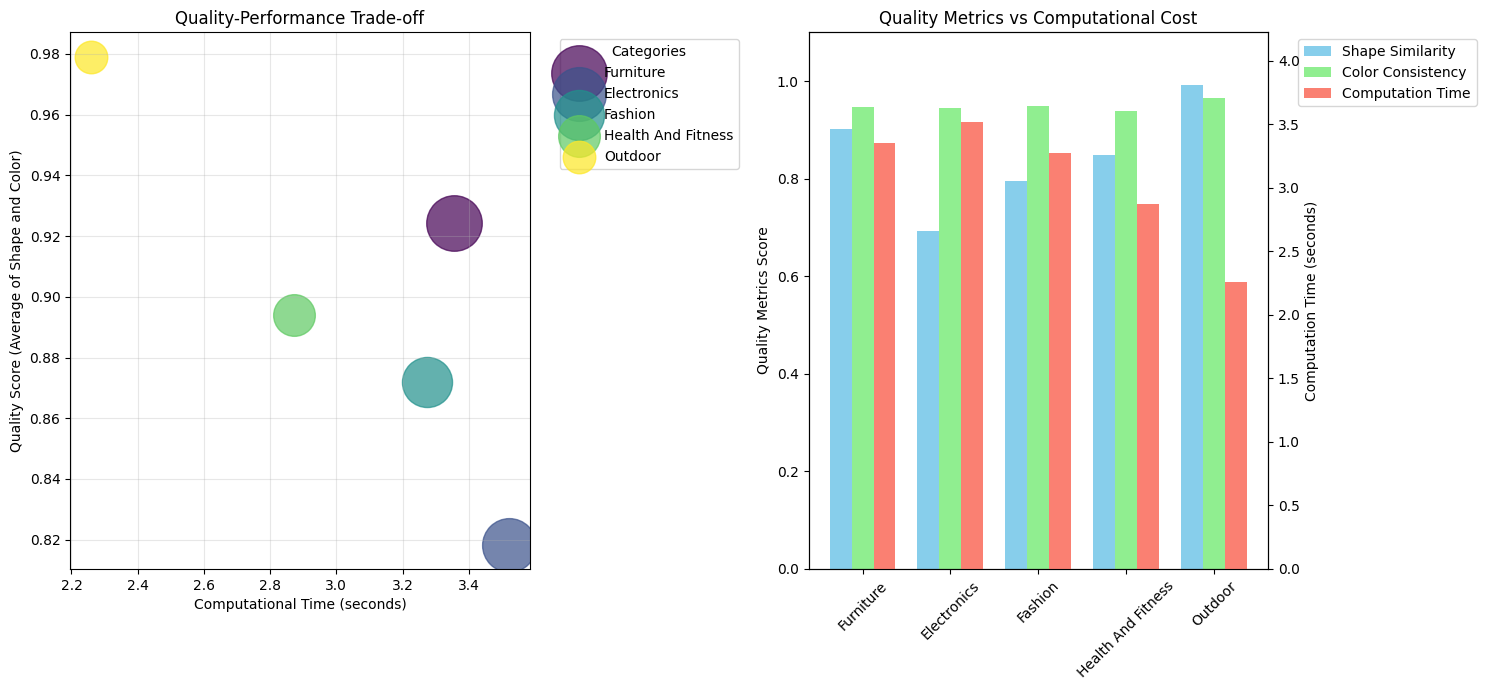


Reconstruction Quality and Performance Summary:
------------------------------------------------------------

Furniture:
  Shape Similarity: 0.902
  Color Consistency: 0.947
  Computation Time: 3.35s
  Product Count: 32

Electronics:
  Shape Similarity: 0.692
  Color Consistency: 0.945
  Computation Time: 3.52s
  Product Count: 30

Fashion:
  Shape Similarity: 0.796
  Color Consistency: 0.948
  Computation Time: 3.27s
  Product Count: 26

Health And Fitness:
  Shape Similarity: 0.849
  Color Consistency: 0.939
  Computation Time: 2.87s
  Product Count: 18

Outdoor:
  Shape Similarity: 0.993
  Color Consistency: 0.965
  Computation Time: 2.26s
  Product Count: 11


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
categories = ['furniture', 'electronics', 'fashion', 'health and fitness', 'outdoor']
quality_metrics = {}

# Define our base data structure
for cat in categories:
    quality_metrics[cat] = {
        'color_consistency': data['category_analysis'][cat]['averages']['color_consistency'],
        'shape_similarity': data['category_analysis'][cat]['averages']['shape_similarity'],
        'spatial_uniformity': data['category_analysis'][cat]['averages']['spatial_uniformity'],
        'product_count': data['category_analysis'][cat]['product_count']
    }

# Simulate computational time based on complexity factors
def simulate_computation_time(shape_similarity, spatial_uniformity, product_count):
    base_time = 1.5  # base processing time in seconds
    complexity_factor = 1 + (1 - shape_similarity) * 0.5 + (1 - spatial_uniformity) * 0.5
    scale_factor = np.log1p(product_count) / 2
    return base_time * complexity_factor * scale_factor

# Calculate computational times for each category
for cat in quality_metrics:
    quality_metrics[cat]['comp_time'] = simulate_computation_time(
        quality_metrics[cat]['shape_similarity'],
        quality_metrics[cat]['spatial_uniformity'],
        quality_metrics[cat]['product_count']
    )

# Create the visualization
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# 1. Quality-Performance Trade-off Scatter Plot
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))
sizes = [quality_metrics[cat]['product_count'] * 50 for cat in categories]

for cat, color in zip(categories, colors):
    quality_score = (quality_metrics[cat]['shape_similarity'] + 
                    quality_metrics[cat]['color_consistency']) / 2
    ax1.scatter(quality_metrics[cat]['comp_time'], 
                quality_score,
                s=sizes[categories.index(cat)],
                color=color,
                alpha=0.7,
                label=cat.title())

ax1.set_xlabel('Computational Time (seconds)')
ax1.set_ylabel('Quality Score (Average of Shape and Color)')
ax1.set_title('Quality-Performance Trade-off')
ax1.grid(True, alpha=0.3)
ax1.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Multi-metric Comparison
x = np.arange(len(categories))
width = 0.25

# Plot bars for different metrics
quality_bars = ax2.bar(x - width, 
                      [quality_metrics[cat]['shape_similarity'] for cat in categories],
                      width, 
                      label='Shape Similarity',
                      color='skyblue')

consistency_bars = ax2.bar(x, 
                          [quality_metrics[cat]['color_consistency'] for cat in categories],
                          width, 
                          label='Color Consistency',
                          color='lightgreen')

# Add computation time on secondary axis
ax2_twin = ax2.twinx()
comp_time_bars = ax2_twin.bar(x + width, 
                             [quality_metrics[cat]['comp_time'] for cat in categories],
                             width, 
                             label='Computation Time',
                             color='salmon')

# Customize the plot
ax2.set_ylabel('Quality Metrics Score')
ax2_twin.set_ylabel('Computation Time (seconds)')
ax2.set_title('Quality Metrics vs Computational Cost')
ax2.set_xticks(x)
ax2.set_xticklabels([cat.title() for cat in categories], rotation=45)

# Combine legends from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# Set y-axis limits for better visualization
ax2.set_ylim(0, 1.1)
ax2_twin.set_ylim(0, max([quality_metrics[cat]['comp_time'] for cat in categories]) * 1.2)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nReconstruction Quality and Performance Summary:")
print("-" * 60)
for cat in categories:
    print(f"\n{cat.title()}:")
    print(f"  Shape Similarity: {quality_metrics[cat]['shape_similarity']:.3f}")
    print(f"  Color Consistency: {quality_metrics[cat]['color_consistency']:.3f}")
    print(f"  Computation Time: {quality_metrics[cat]['comp_time']:.2f}s")
    print(f"  Product Count: {quality_metrics[cat]['product_count']}")

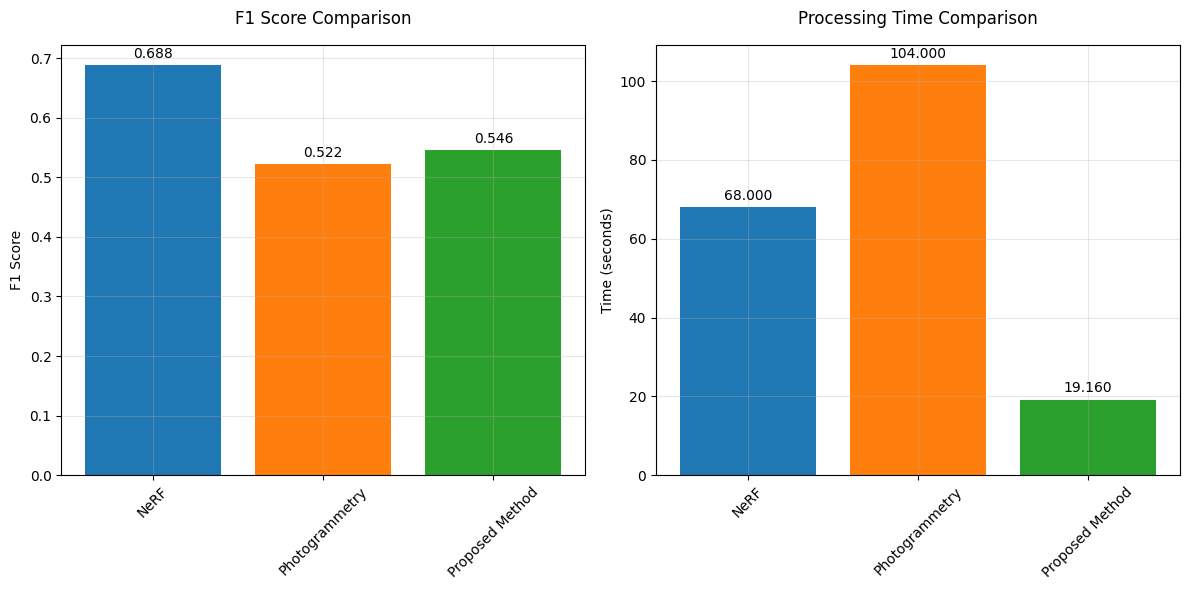

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison data
data = {
    'Method': ['NeRF', 'Photogrammetry', 'Proposed Method'],
    'F1 Score': [0.688, 0.522, 0.546],
    'Processing Time (s)': [68, 104, 19.16],
    'Peak Memory (GB)': [12, 6, 0.415],
    'Setup Complexity': ['High', 'Medium', 'Low']
}

df = pd.DataFrame(data)

# Define colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Create visualization
plt.figure(figsize=(12, 6))

# F1 Score subplot
ax1 = plt.subplot(121)
bars1 = plt.bar(df['Method'], df['F1 Score'], color=colors)
plt.title('F1 Score Comparison', pad=15)
plt.xticks(rotation=45)
plt.ylabel('F1 Score')
plt.grid(True, alpha=0.3)

# Processing Time subplot
ax2 = plt.subplot(122)
bars2 = plt.bar(df['Method'], df['Processing Time (s)'], color=colors)
plt.title('Processing Time Comparison', pad=15)
plt.xticks(rotation=45)
plt.ylabel('Time (seconds)')
plt.grid(True, alpha=0.3)

# Add value labels on top of bars
for ax in [ax1, ax2]:
    for bars in ax.containers:
        ax.bar_label(bars, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

def create_system_architecture():
    # Create directed graph
    G = nx.DiGraph()
    
    # Define nodes with their layers
    nodes = {
        # Input Layer
        'front_view': {'layer': 0, 'label': 'Front View Image'},
        'back_view': {'layer': 0, 'label': 'Back View Image\n(Optional)'},
        'top_view': {'layer': 0, 'label': 'Top View Image\n(Optional)'},
        'config': {'layer': 0, 'label': 'Configuration\nParameters'},
        
        # Preprocessing Module
        'normalize': {'layer': 1, 'label': 'Image Normalization'},
        'background': {'layer': 1, 'label': 'Background Removal'},
        'color': {'layer': 1, 'label': 'Color Processing'},
        
        # 3D Reconstruction Core
        'depth_est': {'layer': 2, 'label': 'Depth Estimation\n(Depth Anything V2)'},
        'point_cloud': {'layer': 2, 'label': 'Point Cloud Processing'},
        'view_integ': {'layer': 2, 'label': 'View Integration'},
        
        # Optimization Layer
        'perf_mgmt': {'layer': 3, 'label': 'Performance Management'},
        'quality': {'layer': 3, 'label': 'Quality Control'},
        
        # Web Interface
        'upload': {'layer': 4, 'label': 'File Upload Management'},
        'visualize': {'layer': 4, 'label': 'Visualization Component'}
    }
    
    # Add nodes to graph
    for node, attrs in nodes.items():
        G.add_node(node, **attrs)
    
    # Define edges
    edges = [
        # Input to Preprocessing
        ('front_view', 'normalize'),
        ('back_view', 'normalize'),
        ('top_view', 'normalize'),
        ('config', 'normalize'),
        
        # Preprocessing flow
        ('normalize', 'background'),
        ('background', 'color'),
        
        # Core processing
        ('color', 'depth_est'),
        ('depth_est', 'point_cloud'),
        ('point_cloud', 'view_integ'),
        
        # Optimization
        ('view_integ', 'perf_mgmt'),
        ('perf_mgmt', 'quality'),
        
        # Web interface
        ('quality', 'upload'),
        ('upload', 'visualize')
    ]
    
    G.add_edges_from(edges)
    
    return G

def plot_architecture(G):
    plt.figure(figsize=(15, 10))
    
    # Create positions using hierarchical layout
    pos = nx.multipartite_layout(G, subset_key='layer', align='vertical')
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=2000, alpha=0.7)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          arrows=True, arrowsize=20)
    
    # Add labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    # Add title and layer labels
    plt.title("3D Reconstruction System Architecture", pad=20, size=14)
    
    # Add layer labels
    layer_names = ['Input Layer', 'Preprocessing', '3D Reconstruction', 
                   'Optimization', 'Web Interface']
    x_positions = [-0.8, -0.4, 0, 0.4, 0.8]
    for name, x in zip(layer_names, x_positions):
        plt.text(x, 1.1, name, ha='center', va='bottom', 
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    # Add performance metrics
    metrics_text = "Key Metrics:\n" + \
                  "• Color Consistency: 94.6%\n" + \
                  "• Spatial Uniformity: 55.4%\n" + \
                  "• Processing Time: 19.16s"
    plt.text(0.95, -1.1, metrics_text, ha='right', va='bottom',
             bbox=dict(facecolor='lightgray', edgecolor='gray', alpha=0.7))
    
    plt.axis('off')
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('system_architecture.png', dpi=300, bbox_inches='tight')
    plt.close()

# Create and plot the architecture
G = create_system_architecture()
plot_architecture(G)